## Prediciendo la diabetes usando algoritmo de random forest

Este conjunto de datos proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales. El objetivo es predecir en base a medidas diagnósticas si un paciente tiene o no diabetes.

En este notebook se usa el mismo dataset usado anteriormente en el noteboook de predicción de la diabetes con árboles de decisión, por tanto no se profundiza en el eda ya que se hizo en el anterior proyecto y aca buscamos implementar el modelo de random search.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

from sklearn.tree import DecisionTreeClassifier
# from sklearn.tree import DecisionTreeRegressor para regresion
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.drop(columns=['SkinThickness', 'Insulin'],  inplace=True) #se eliminan cols con mas nulos

In [6]:
# La condición para filas con ceros en esas columnas
condicion = (df['BloodPressure'] == 0) | (df['BMI'] == 0) | (df['Glucose'] == 0)

# Obtener los índices de las filas a eliminar
indices_a_eliminar = df.loc[condicion].index

# Eliminar esas filas directamente en df
df.drop(indices_a_eliminar, inplace=True)

print(f"Filas restantes después de eliminar: {len(df)}")
# Filas restantes después de eliminar: 724

Filas restantes después de eliminar: 724


In [7]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mostrar tamaños de los subconjuntos
print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)
print("Tamaño y_train:", y_train.shape)
print("Tamaño y_test:", y_test.shape)

Tamaño X_train: (579, 6)
Tamaño X_test: (145, 6)
Tamaño y_train: (579,)
Tamaño y_test: (145,)


In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state = 42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


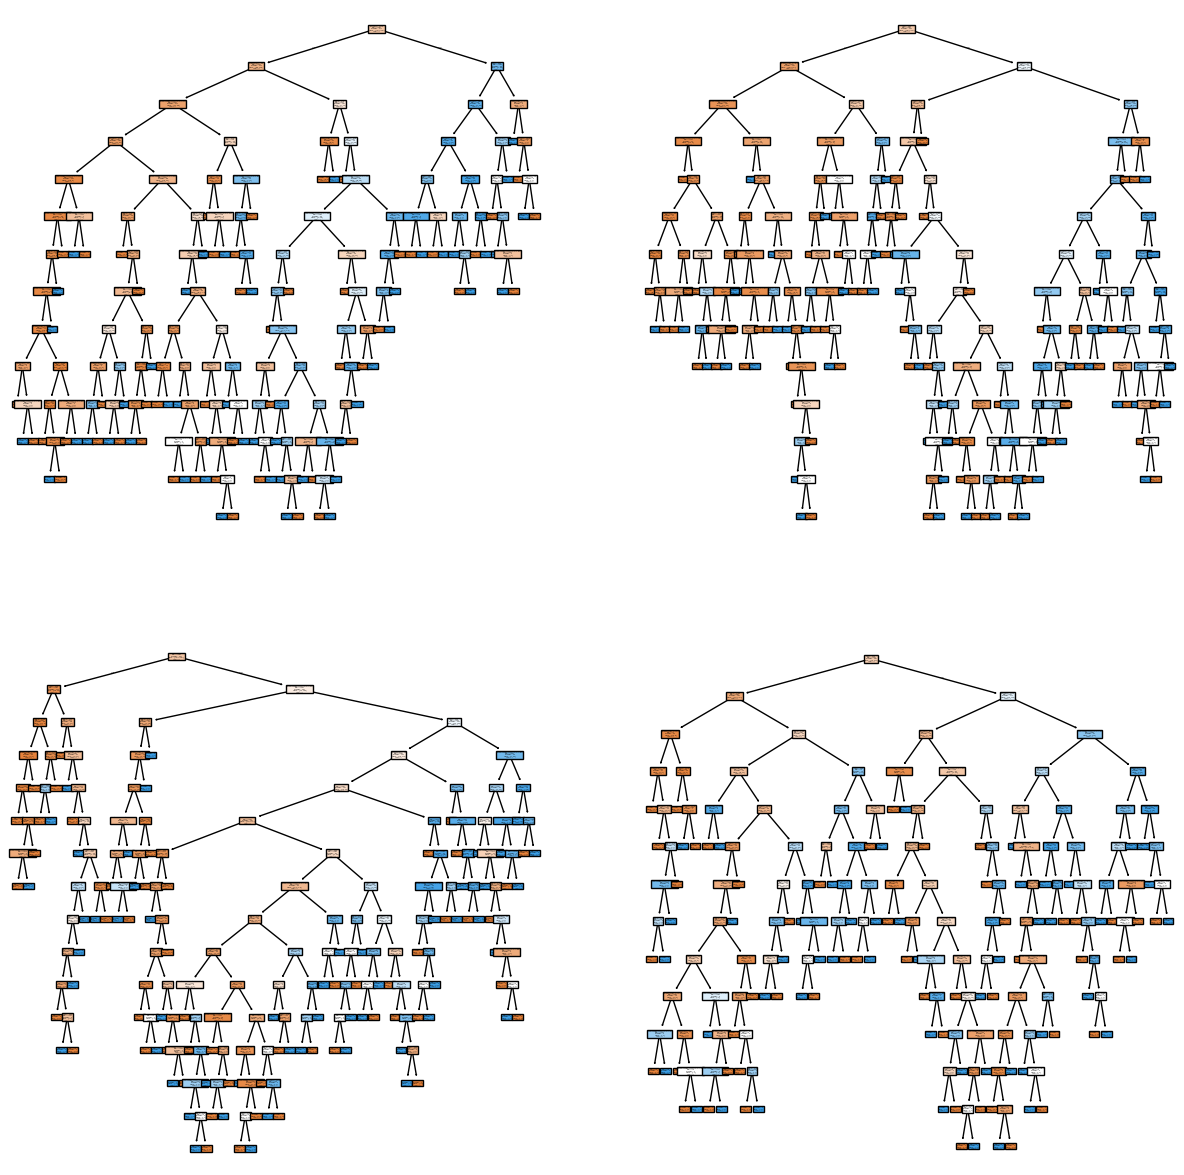

In [9]:
import matplotlib.pyplot as plt
from sklearn import tree

fig, axis = plt.subplots(2, 2, figsize = (15, 15))

# Mostramos los 4 primeros árboles de los 100 generados (por defecto)
tree.plot_tree(model.estimators_[0], ax = axis[0, 0], feature_names = list(X_train.columns), class_names = ["0", "1", "2"], filled = True)
tree.plot_tree(model.estimators_[1], ax = axis[0, 1], feature_names = list(X_train.columns), class_names = ["0", "1", "2"], filled = True)
tree.plot_tree(model.estimators_[2], ax = axis[1, 0], feature_names = list(X_train.columns), class_names = ["0", "1", "2"], filled = True)
tree.plot_tree(model.estimators_[3], ax = axis[1, 1], feature_names = list(X_train.columns), class_names = ["0", "1", "2"], filled = True)

plt.show()

In [10]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0])

In [11]:
from sklearn.metrics import f1_score

In [12]:
from sklearn.metrics import accuracy_score

f1_score(y_test, y_pred)

0.6818181818181818

In [13]:
## Reporte de clasificación
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86       102
           1       0.67      0.70      0.68        43

    accuracy                           0.81       145
   macro avg       0.77      0.78      0.77       145
weighted avg       0.81      0.81      0.81       145



## Optimización de hiperparámetros

### Random Search

In [14]:
from scipy.stats import randint
# Definir el espacio de búsqueda con distribuciones aleatorias
# Espacio de búsqueda para hiperparámetros
rf_random = {
    "n_estimators": np.arange(200, 600, 100),
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": np.arange(2, 20, 2),
    "min_samples_leaf": np.arange(2, 20, 2),
    "max_features": [1, 2, 3, 4, "sqrt", "log2"]
}

# Mejorar los parametros, primero de forma global y después de forma mas ajustada, mas reducida para mejorar resultados !!


# Crear el modelo base
rf_model = RandomForestClassifier(random_state=42)

# Optimización con RandomizedSearchCV
rs_model = RandomizedSearchCV(
    rf_model,
    param_distributions=rf_random,
    scoring="f1",  # o "roc_auc", "f1", "precision", "recall"
    n_iter=20,
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1  # Usa todos los núcleos
)

# Entrenar
rs_model.fit(X_train, y_train)


print("Mejores hiperparámetros encontrados:")
print(rs_model.best_params_)
print("Mejor f1_score promedio:", rs_model.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros encontrados:
{'n_estimators': np.int64(500), 'min_samples_split': np.int64(6), 'min_samples_leaf': np.int64(12), 'max_features': 4, 'max_depth': 10}
Mejor f1_score promedio: 0.6389766447488088


In [15]:
# Obtener el mejor modelo encontrado
best_model = rs_model.best_estimator_

# Hacer predicciones en el conjunto de prueba
y_best_pred = best_model.predict(X_test)

# Evaluar
print("🔍 Evaluación del modelo optimizado en el conjunto de prueba:")
print("f1_score:", f1_score(y_test, y_best_pred))
print(classification_report(y_test, y_best_pred))

🔍 Evaluación del modelo optimizado en el conjunto de prueba:
f1_score: 0.6746987951807228
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       102
           1       0.70      0.65      0.67        43

    accuracy                           0.81       145
   macro avg       0.78      0.77      0.77       145
weighted avg       0.81      0.81      0.81       145



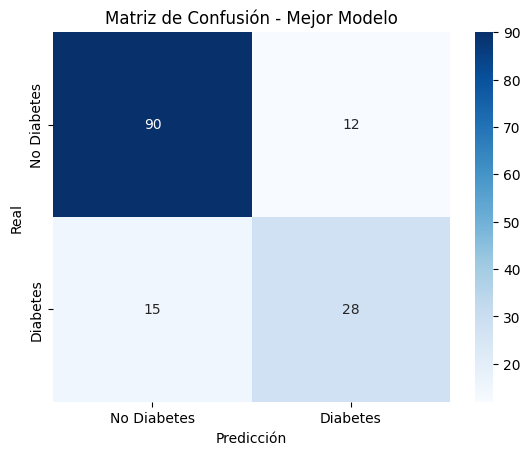

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de confusión
cm = confusion_matrix(y_test, y_best_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Diabetes", "Diabetes"], yticklabels=["No Diabetes", "Diabetes"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Mejor Modelo")
plt.show()

### Grid search

In [17]:
param_grid = {
    "n_estimators": [400,500],
    "max_depth": [None, 10],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1,2,3],
    "max_features":  [3] #["sqrt", "log2"]
}


# Crear el modelo base
rf_model = RandomForestClassifier(random_state=42)

# Configurar GridSearchCV
gs_model = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Entrenamiento
gs_model.fit(X_train, y_train)

# Resultados
print("Mejores hiperparámetros encontrados (GridSearch):")
print(gs_model.best_params_)
print("Mejor f1_score en validación cruzada:", gs_model.best_score_)

# Evaluación en conjunto de prueba
best_model = gs_model.best_estimator_
y_pred = best_model.predict(X_test)

print("\n🔍 Evaluación del modelo optimizado en el conjunto de prueba:")
print("f1_score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores hiperparámetros encontrados (GridSearch):
{'max_depth': 10, 'max_features': 3, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 500}
Mejor f1_score en validación cruzada: 0.6357123499806426

🔍 Evaluación del modelo optimizado en el conjunto de prueba:
f1_score: 0.6976744186046512
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       102
           1       0.70      0.70      0.70        43

    accuracy                           0.82       145
   macro avg       0.79      0.79      0.79       145
weighted avg       0.82      0.82      0.82       145



### Bayes Search

In [ ]:
# pip install scikit-optimize

In [18]:
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical

search_spaces = {
    "n_estimators": (200,400,500,800),         # rango entero continuo
     "max_depth": Categorical([None, 5, 10, 15, 20]),              # rango entero continuo
    "min_samples_split": Integer(2, 20),       # rango entero continuo
    "min_samples_leaf": Integer(1, 10),        # rango entero continuo
    "max_features": Categorical(['sqrt', 'log2',2,3])  # valores categóricos y continuos
}

# Modelo base
rf_model = RandomForestClassifier(random_state=42)

# BayesSearchCV
bayes_search = BayesSearchCV(
    estimator=rf_model,
    search_spaces=search_spaces,
    n_iter=50,             # número de iteraciones
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
bayes_search.fit(X_train, y_train)

# Resultados
print("Mejores hiperparámetros encontrados (Bayesian Search):")
print(bayes_search.best_params_)
print("Mejor f1_score en validación cruzada:", bayes_search.best_score_)

# Evaluar en conjunto de prueba
best_model = bayes_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n🔍 Evaluación del modelo optimizado en el conjunto de prueba:")
print("f1_score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

## Conclusiones

Metrica f1 con los 3 metodos de optimización:
Grid Search:
Mejores parámetros encontrados:

'max_depth': 10, 'max_features': 3, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 500

Mejor f1_score en validación cruzada: 0.6357123499806426 Accuracy en conjunto de prueba: 0.6976

Random Search:
Mejores parámetros encontrados: n_estimators': np.int64(500), 'min_samples_split': np.int64(6), 'min_samples_leaf': np.int64(12), 'max_features': 4, 'max_depth': 10

F1 promedio en validación cruzada: 0.6389766447488088 Accuracy en conjunto de prueba: 0.6746

Bayes search
Mejores parámetros encontrados: ('max_depth', 5), ('max_features', 'log2'), ('min_samples_leaf', 1), ('min_samples_split', 2), ('n_estimators', 400)

F1 promedio en validación cruzada: 0.642

Accuaracy en conjunto de prueba: 0.666

Conclusión:
La optimización por GridSearch tiene mejores resultados en el conjunto de prueba, con un f1 score de 0.6976, el más alto.